# 12_时间序列分析方法-自回归积分滑动平均

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。
- 原任意的 ±10% 阴影替换为模型预测区间；明确全量拟合图是样本内结果，另外保留末尾 90 天评估样本外误差。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


本文和大家详细的聊聊时间序列中的**自回归积分滑动平均**\~

**自回归积分滑动平均是什么？**

「自回归积分滑动平均模型」（**ARIMA** 模型）是时间序列分析中一种常见的预测方法。它可以帮助我们从历史数据中发现规律，并对未来进行预测。这个模型的名称反映了它的三个重要组成部分：自回归（AR）、差分（I，即积分）、和滑动平均（MA）。我们可以从简单的概念开始理解它，并用一个通俗的例子来解释。

### 1. **自回归（AR, Autoregressive）**

自回归的意思是，我们使用之前的数据点来预测未来的数据。例如，如果你想知道今天的温度，可以假设今天的温度和昨天、前天等的温度有一定的关系。这就是**自回归模型**的核心思想。

**例子：**  
假设我们有以下几天的温度记录（以摄氏度为单位）：

- 第一天：15°C
- 第二天：16°C
- 第三天：16.5°C
- 第四天：17°C

如果我们用自回归模型来预测第五天的温度，我们可以假设第五天的温度和前几天的温度成某种线性关系，公式如下：


$$
T_{t} = \phi_1 T_{t-1} + \phi_2 T_{t-2} + \cdots + \phi_p T_{t-p} + \epsilon_t
$$


其中，$T_{t}$是第 $t$天的温度，$\phi_1, \phi_2, \dots, \phi_p$是模型的参数， $\epsilon_t$是误差项。

### 2. **差分（I, Integration）**

现实中，很多时间序列数据并不是平稳的，比如气温有时候会呈现上升或下降趋势，而不是固定在某个区间波动。为了让数据更易于建模，我们对数据进行“差分”，也就是计算相邻两天的温度变化。这种变化可以让模型更加准确地捕捉到趋势。  
差分指的是当前值与前一值的差：  
$\Delta T_t = T_t - T_{t-1}$

继续上面的温度数据：

- 第一天到第二天的差：16°C - 15°C = 1°C
- 第二天到第三天的差：16.5°C - 16°C = 0.5°C
- 第三天到第四天的差：17°C - 16.5°C = 0.5°C

通过差分，我们可以将原本可能有趋势的温度序列转化为一个相对稳定的变化量序列。

### 3. **滑动平均（MA, Moving Average）**

滑动平均模型假设未来的数据点不仅取决于过去的数值，还取决于过去的预测误差。它的作用是平滑掉由于偶然因素引起的波动，使得预测更加稳定。

公式：  
$T_t = \mu + \theta_1 \epsilon_{t-1} + \theta_2 \epsilon_{t-2} + \cdots + \theta_q \epsilon_{t-q} + \epsilon_t$

其中， $\epsilon_t$是每个时刻的误差，$\theta_1, \theta_2, \dots, \theta_q$是模型参数，$\mu$是常数项。  
假设在前几天预测温度时，我们的预测误差分别是：

- 第一天的误差：+0.5°C
- 第二天的误差：-0.2°C
- 第三天的误差：+0.1°C

滑动平均模型会根据这些误差调整接下来的预测值。

#### **ARIMA 模型总结**

ARIMA 模型就是将这三部分结合起来：

- **AR（自回归）：** 用过去的数值来预测未来；
- **I（差分）：** 通过差分将非平稳的时间序列转化为平稳序列；
- **MA（滑动平均）：** 通过过去的预测误差来校正未来的预测。

#### **案例：ARIMA(1,1,1) 模型的应用**

假设我们有以下五天的销售数据：

- 第一天：100 单
- 第二天：102 单
- 第三天：105 单
- 第四天：107 单
- 第五天：110 单

我们想预测第六天的销售量。

**1. 差分（I=1）：**

我们首先计算相邻两天的差值：

- 第一天到第二天的差：102 - 100 = 2
- 第二天到第三天的差：105 - 102 = 3
- 第三天到第四天的差：107 - 105 = 2
- 第四天到第五天的差：110 - 107 = 3

差分后的数据序列是：2, 3, 2, 3。

**2. 自回归（AR=1）：**

现在我们用这个差分后的数据来建立自回归模型。假设我们用第 $t-1$天的差值来预测第 $t$天的差值，模型形式为：  
$\Delta T_t = \phi \Delta T_{t-1} + \epsilon_t$

假设 $\phi = 0.5$，那么第六天的差值可以预测为：  
$\Delta T_6 = 0.5 \times \Delta T_5 = 0.5 \times 3 = 1.5$

**3. 滑动平均（MA=1）：**

假设之前的预测误差为 $\epsilon_5 = 0.2$，我们用滑动平均模型调整第六天的预测：  
$T_6 = \mu + \theta_1 \epsilon_5 + \epsilon_6$  
假设 $\mu = 108$且 $\theta_1 = 0.3$，第六天的预测值可以调整为：  
$T_6 = 108 + 0.3 \times 0.2 = 108.06$

**结果：**

根据这个 ARIMA(1,1,1) 模型，我们预测第六天的销售量为 108.06 单。

ARIMA 模型通过自回归、差分和滑动平均三者结合，能够处理具有趋势和季节性等复杂结构的时间序列数据。通过差分稳定数据，通过自回归和滑动平均进行预测，可以在多种实际应用中帮助我们作出更准确的预测。

## 公式解析

ARIMA模型，即自回归积分滑动平均模型，结合了自回归（AR）、差分（I）和滑动平均（MA）三种成分。

### 一、ARIMA 模型的概述

ARIMA模型的全称是 **Autoregressive Integrated Moving Average**，表示自回归、积分和滑动平均三部分。它可以表示为 ARIMA($p, d, q$)，其中：

$p$ 是自回归（AR）部分的阶数，即考虑前 $p$ 个滞后值。

$d$ 是差分（I，积分）的次数，用来处理非平稳时间序列，使之变得平稳。

$q$ 是滑动平均（MA）部分的阶数，即考虑前 $q$ 个误差项。

模型的通用公式是：


$$
\text{ARIMA}(p, d, q) = \phi(B) \nabla^d y_t = \theta(B) \epsilon_t
$$


其中：

- $y_t$是观察值的时间序列。
- $\epsilon_t$是白噪声（误差项）。
- $\phi(B)$是自回归部分的多项式，表示滞后值的影响。
- $\theta(B)$是滑动平均部分的多项式，表示滞后误差的影响。
- $\nabla^d$是差分运算符，用于将非平稳数据转化为平稳数据。

### 二、时间序列的差分

差分操作用于处理非平稳时间序列。差分运算符 $\nabla$表示当前值与前一时刻值的差：


$$
\nabla y_t = y_t - y_{t-1}
$$


**一次差分**（$d=1$）：  
$\nabla y_t = y_t - y_{t-1}$

**二次差分**（$d=2$）：  
$\nabla^2 y_t = \nabla (\nabla y_t) = (y_t - y_{t-1}) - (y_{t-1} - y_{t-2}) = y_t - 2y_{t-1} + y_{t-2}$

一般地，$d$ **次差分**可以写作：  
$\nabla^d y_t = (1 - B)^d y_t$  
其中 $B$是滞后算子（lag operator），定义为 $B^k y_t = y_{t-k}$。

### 三、自回归（AR）部分

自回归模型是指当前值可以通过一组前面时刻的值的线性组合来表示，常见的AR($p$)模型表示如下：


$$
y_t = \phi_1 y_{t-1} + \phi_2 y_{t-2} + \cdots + \phi_p y_{t-p} + \epsilon_t
$$


简写为：


$$
\phi(B) y_t = \epsilon_t
$$


其中 $\phi(B)$是一个多项式，自回归部分的滞后算子：


$$
\phi(B) = 1 - \phi_1 B - \phi_2 B^2 - \cdots - \phi_p B^p
$$


假设时间序列当前值 $y_t$ 是前 $p$ 个值的加权和，再加上一个白噪声项 $\epsilon_t$。AR部分的目的是通过滞后算子将这种线性关系简洁化表示。

### 四、滑动平均（MA）部分

滑动平均模型是指当前值不仅依赖于前一时刻的观测值，还依赖于过去的误差项（即白噪声）。MA($q$)模型的公式如下：


$$
y_t = \epsilon_t + \theta_1 \epsilon_{t-1} + \theta_2 \epsilon_{t-2} + \cdots + \theta_q \epsilon_{t-q}
$$


简写为：


$$
y_t = \theta(B) \epsilon_t
$$


其中 $\theta(B)$是滑动平均部分的滞后算子：


$$
\theta(B) = 1 + \theta_1 B + \theta_2 B^2 + \cdots + \theta_q B^q
$$


在MA部分，预测值是当前白噪声项 $\epsilon_t$ 以及过去 $q$ 个白噪声项的加权和。通过滞后算子简化公式书写。

### 五、整合模型：ARIMA($p,d,q$)

ARIMA模型的核心是将自回归（AR）、差分（I）和滑动平均（MA）三部分结合起来。完整的ARIMA($p,d,q$)模型公式为：


$$
\phi(B) \nabla^d y_t = \theta(B) \epsilon_t
$$


**推导：**

1. 首先，通过 $d$ 次差分操作 $\nabla^d$，我们将原始的非平稳序列 $y_t$转化为平稳序列。
2. 然后，平稳的序列通过AR($p$)的滞后值和MA($q$)的滞后误差项来描述。
3. 最终的模型可以通过滞后算子 $\phi(B)$和 $\theta(B)$表达，将过去的滞后值和误差综合起来，预测当前的 $y_t$。

### 六、示例推导过程：ARIMA(1,1,1)

假设我们有一个时间序列 $y_t$，并拟合一个 ARIMA(1,1,1) 模型。

**1. 差分部分（**$d=1$**）：**

我们对序列进行一次差分：  
$\nabla y_t = y_t - y_{t-1}$

**2. 自回归部分（**$p=1$**）：**

我们假设差分后的序列 $\nabla y_t$可以通过前一个滞后值表示：  
$\nabla y_t = \phi_1 \nabla y_{t-1} + \epsilon_t$  
其中 $\epsilon_t$是白噪声。

**3. 滑动平均部分（**$q=1$**）：**

预测误差不仅仅依赖当前的白噪声，还依赖于前一个滞后误差：  
$\nabla y_t = \theta_1 \epsilon_{t-1} + \epsilon_t$

**4. 完整模型：**

ARIMA(1,1,1) 的完整形式如下：  
$(1 - \phi_1 B) \nabla y_t = (1 + \theta_1 B) \epsilon_t$

替换差分运算符：  
$(1 - \phi_1 B) (1 - B) y_t = (1 + \theta_1 B) \epsilon_t$

这就是ARIMA(1,1,1)的完整数学表达。

ARIMA模型的核心是将时间序列分解为三个部分：自回归、差分和滑动平均。通过差分操作将非平稳数据变为平稳数据，然后用AR部分描述过去值的滞后效应，用MA部分描述过去误差的滞后效应，结合这些要素就可以对未来进行预测。

## 优缺点和适用场景

### ARIMA 模型的优缺点

##### **优点**

**1. 适合处理平稳时间序列：**

ARIMA 模型通过差分处理可以将非平稳的时间序列转化为平稳序列，使其能够有效捕捉数据的趋势和季节性变化。

**2. 模型解释性强：**

ARIMA 的三部分（自回归、差分、滑动平均）都具有明确的物理意义，自回归部分反映过去观测值对当前的影响，滑动平均部分反映过去预测误差对当前预测的影响。因此，模型能够清晰地解释时间序列数据的结构。

**3. 灵活性高：**

通过调整 ARIMA 模型的三个参数 $p$、$d$、$q$，可以针对不同类型的时间序列灵活建模，包括趋势型数据和季节性数据。

**4. 广泛应用于单变量时间序列：**

ARIMA 模型特别适合用于单一时间序列数据的预测，对大量具有历史趋势或季节性的数据表现良好。

##### **缺点**

**1. 对数据要求高：**

ARIMA 模型需要数据是平稳的，或者至少可以通过差分变为平稳。如果数据的季节性太强或者含有复杂的非线性结构，ARIMA 的效果可能不好。

**2. 对长远预测不准确：**

ARIMA 模型依赖于滞后值，因此对于长期预测（尤其是远远超出观测窗口的预测）效果较差。它更适合短期预测。

**3. 无法处理多元时间序列：**

ARIMA 只能处理单一时间序列，对于多元时间序列，必须使用其他模型（如 VAR 模型）。

**4. 需要人工确定参数：**

模型的 $p$、$d$、$q$ 需要通过一些统计方法和试探来确定，可能存在一定的复杂度，尤其是对于新手来说。

**5. 对极端值敏感：**

ARIMA 对异常值（outliers）较为敏感，如果数据中有极端值，可能会对模型的预测精度产生较大影响。

### ARIMA 模型的适用场景

**1. 稳定的时间序列预测：**

ARIMA 模型非常适合对具有趋势或者季节性但可以通过差分处理变为平稳的数据进行预测。例如，销售数据、股票价格、温度变化等都可以使用 ARIMA 模型。

**2. 短期预测：**

ARIMA 在短期预测中的表现通常优于长期预测，因为它基于过去的滞后值和误差来预测未来的变化，所以在数据具有短期依赖性的场景下，ARIMA 效果较好。

**3. 单变量时间序列：**

当只有一个变量的历史数据可用时，ARIMA 是一个合适的选择，尤其是对历史数据没有明显的复杂依赖关系时。

**4. 经济和金融时间序列分析：**

在经济和金融领域，ARIMA 被广泛应用于市场趋势预测、股票价格走势预测、宏观经济指标分析（如 GDP、CPI、汇率等）。

## 完整案例

我们创建一个虚拟数据集来模拟实际场景中的销售情况。这个虚拟数据集将包括季节性变化、趋势和噪声，并且我们会使用 ARIMA 模型对该数据进行预测。

在新的虚拟数据集中，假设：

- **趋势**：销售数据呈现增长趋势。
- **季节性**：每年有周期性的销售波动，例如节假日期间销售高峰。
- **随机噪声**：引入一些随机噪声以模拟真实数据中的波动性。

下面是完整的 Python 代码，生成虚拟销售数据并使用 ARIMA 模型进行分析和可视化。

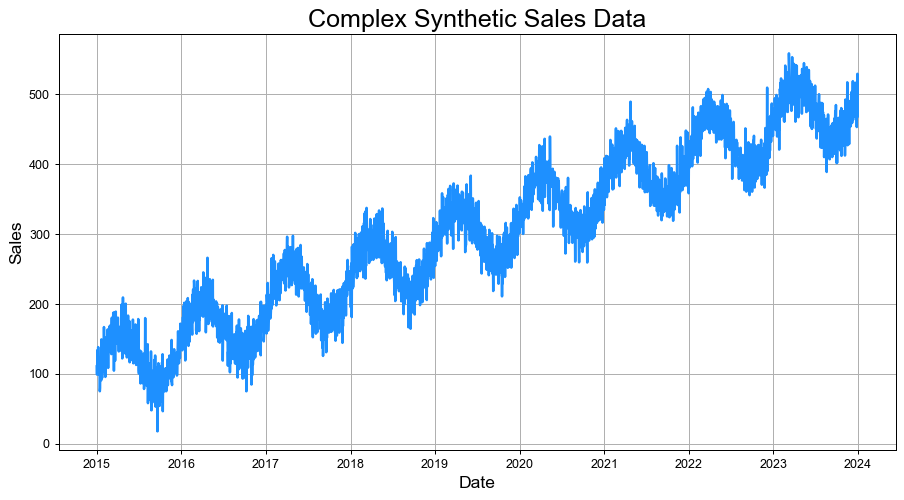

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


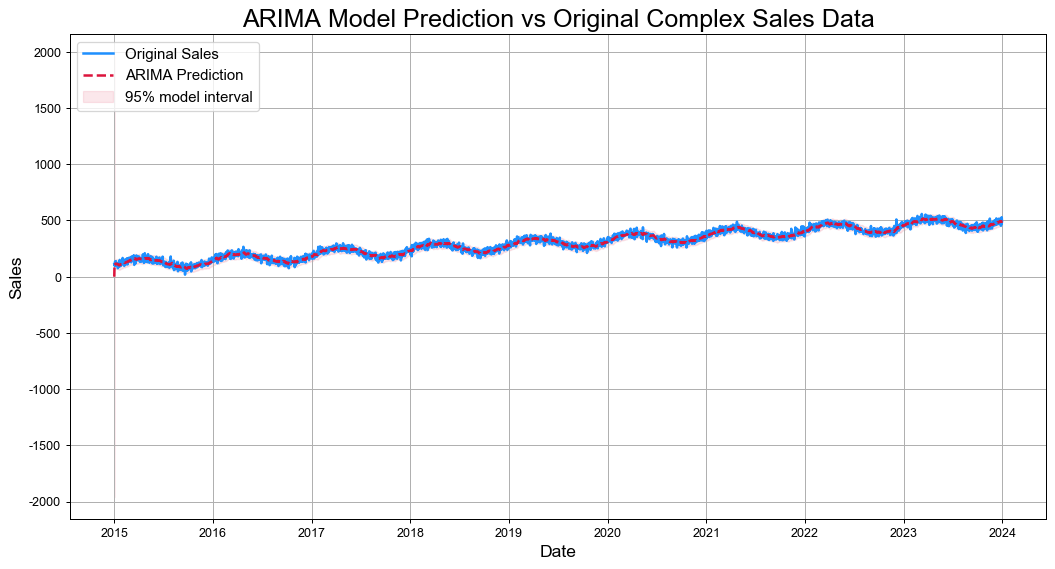

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 生成复杂的虚拟销售数据
np.random.seed(42)
date_rng = pd.date_range(start='1/1/2015', end='12/31/2023', freq='D')  # 日期范围：2015年到2023年
n = len(date_rng)

# 创建趋势 + 季节性 + 随机噪声的虚拟销售数据
trend = np.linspace(100, 500, n)  # 销售增长趋势
seasonality = 50 * np.sin(2 * np.pi * date_rng.dayofyear / 365.25)  # 每年周期性波动
noise = np.random.normal(0, 20, n)  # 随机噪声

# 将三部分叠加生成销售数据
sales = trend + seasonality + noise

# 将数据放入DataFrame
df = pd.DataFrame(date_rng, columns=['Date'])
df['Sales'] = sales
df.set_index('Date', inplace=True)

# 数据可视化 - 虚拟销售数据
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Sales'], color='dodgerblue', linewidth=2)
plt.title('Complex Synthetic Sales Data', fontsize=20)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Sales', fontsize=14)
plt.grid(True)
plt.show()

# 构建 ARIMA 模型 (假设 p=5, d=1, q=2)
model = ARIMA(df['Sales'], order=(5, 1, 2))
arima_result = model.fit()

# ARIMA 模型预测
df['ARIMA_Prediction'] = arima_result.predict(start=0, end=len(df)-1, dynamic=False)

# 绘制 ARIMA 预测结果和原始数据对比图
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Sales'], label='Original Sales', color='dodgerblue', linewidth=2)
plt.plot(df.index, df['ARIMA_Prediction'], label='ARIMA Prediction', color='crimson', linestyle='--', linewidth=2)
prediction_ci = arima_result.get_prediction(start=0, end=len(df)-1).conf_int()
plt.fill_between(df.index, prediction_ci.iloc[:, 0], prediction_ci.iloc[:, 1], color='crimson', alpha=0.1, label='95% model interval')
plt.title('ARIMA Model Prediction vs Original Complex Sales Data', fontsize=20)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Sales', fontsize=14)
plt.legend(loc='upper left', fontsize=12)
plt.grid(True)
plt.show()

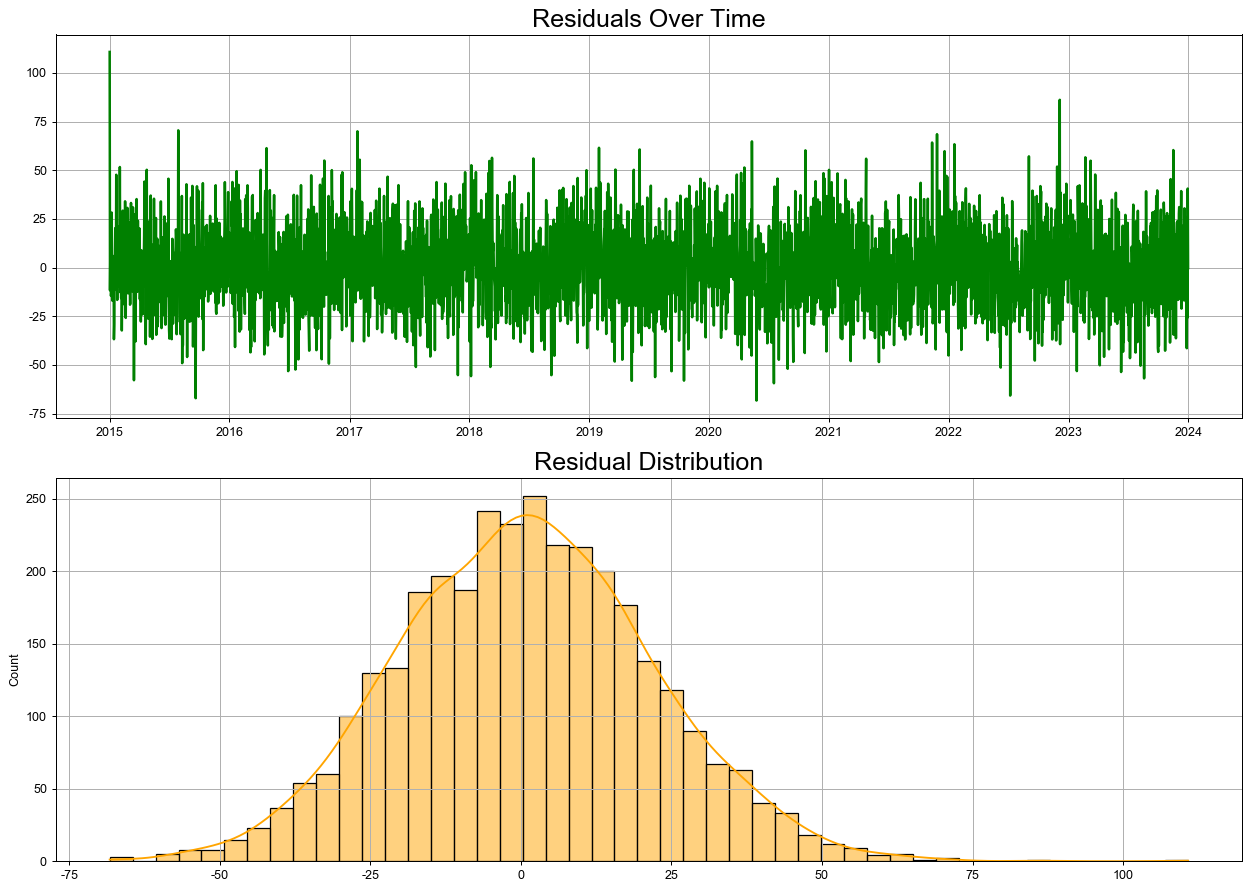

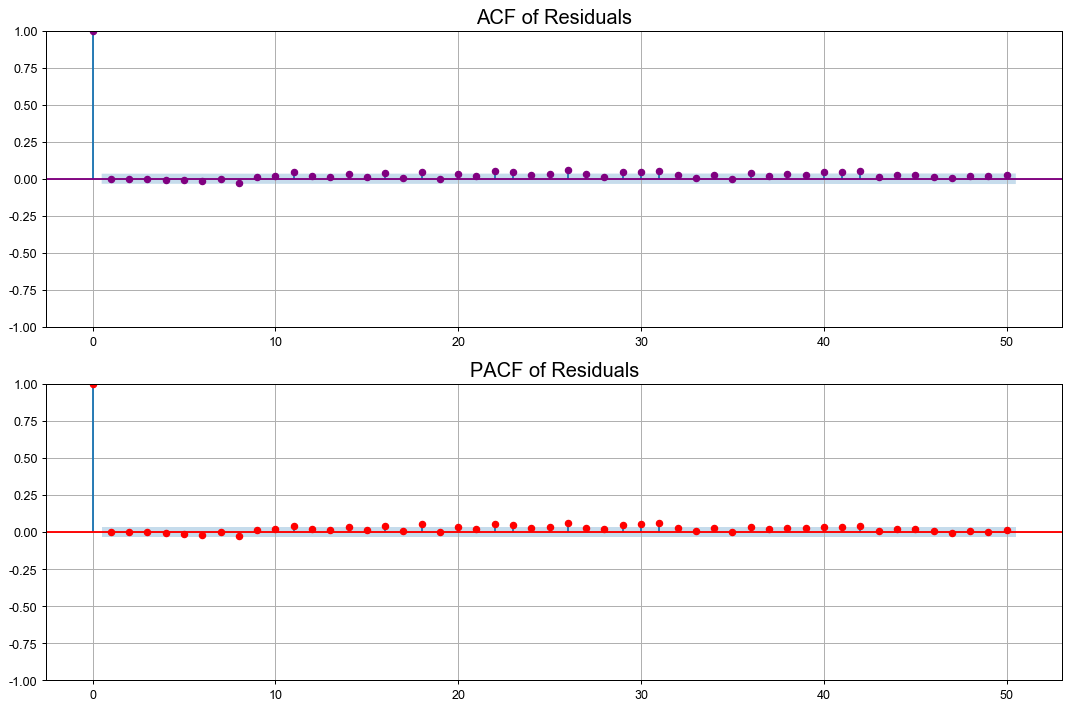

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Held-out RMSE: 39.05104859097263


In [3]:
# 残差分析图 (炫酷的残差分布)
residuals = arima_result.resid
fig, ax = plt.subplots(2, 1, figsize=(14, 10))

# 残差时间序列图
ax[0].plot(residuals, color='green', linestyle='-', linewidth=2)
ax[0].set_title('Residuals Over Time', fontsize=20)
ax[0].grid(True)

# 残差分布直方图
sns.histplot(residuals, kde=True, color='orange', ax=ax[1])
ax[1].set_title('Residual Distribution', fontsize=20)
ax[1].grid(True)

plt.tight_layout()
plt.show()

# ACF 和 PACF 图形展示
fig, ax = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(residuals, lags=50, ax=ax[0], color='purple')
ax[0].set_title('ACF of Residuals', fontsize=16)
ax[0].grid(True)

plot_pacf(residuals, lags=50, ax=ax[1], color='red')
ax[1].set_title('PACF of Residuals', fontsize=16)
ax[1].grid(True)

plt.tight_layout()
plt.show()
# 单独保留末尾 90 天做样本外预测，区别于上面的样本内拟合图。
from sklearn.metrics import mean_squared_error
train_series, test_series = df['Sales'].iloc[:-90], df['Sales'].iloc[-90:]
heldout_model = ARIMA(train_series, order=(5, 1, 2)).fit()
heldout_forecast = heldout_model.forecast(steps=len(test_series))
print('Held-out RMSE:', np.sqrt(mean_squared_error(test_series, heldout_forecast)))

**1. 生成虚拟数据：**

- **趋势**：使用 `np.linspace` 生成一个从 100 增长到 500 的线性趋势，表示随着时间销售逐渐增加。
- **季节性**：使用 `sin` 函数生成一个年周期的季节性波动，假设销售数据每年有一次销售高峰（如年底假期）。
- **噪声**：使用 `np.random.normal` 添加随机噪声，模拟现实中的销售波动。

2. 数据可视化：绘制虚拟销售数据的趋势和波动情况，直观展示趋势+季节性+噪声的叠加效果。

3. ARIMA 模型预测：使用 ARIMA(5, 1, 2) 模型对虚拟数据进行拟合，预测销售情况。绘制预测结果和原始数据对比图，通过颜色和填充效果突出预测区间的不确定性。

4. 残差分析：绘制残差时间序列图和残差分布的直方图，评估 ARIMA 模型的拟合效果。通过 `sns.histplot` 和 KDE 曲线评估残差的正态性。

5. ACF 和 PACF 分析：绘制残差的自相关函数（ACF）和偏自相关函数（PACF）图，分析残差的相关性，进一步验证模型的适用性。

数据分析图形方面：

**虚拟销售数据图**：清晰地展示了一个包含趋势、季节性和噪声的复杂销售数据集。

![原文参考图，当前结果见代码输出](attachments/img_023.png)

**预测结果对比图**：通过 ARIMA 模型拟合的预测结果与真实数据的对比，带有填充的不确定区域。

![原文参考图，当前结果见代码输出](attachments/img_024.png)

**残差分析图**：残差时间序列和分布情况，能够帮助我们评估模型的拟合质量。

![原文参考图，当前结果见代码输出](attachments/img_025.png)

**ACF 和 PACF 图**：用来分析残差是否仍存在自相关关系，判断模型的拟合是否充分。

![原文参考图，当前结果见代码输出](attachments/img_026.png)

这段代码模拟了一个复杂的销售时间序列，包含趋势、季节性和噪声，并使用 ARIMA 模型进行预测。

大家可以直接运行此代码，调整虚拟数据的复杂性或 ARIMA 模型的参数，以得到不同的分析效果。